In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp

from scipy.sparse import vstack, load_npz
from sklearn.preprocessing import StandardScaler
import sklearn.metrics as skm
import sklearn.utils as sku

import torch as pt
import torch.nn as nn
import torch.optim as optim

from torch.nn import CrossEntropyLoss
from torch.utils.data import Dataset, DataLoader

import optuna as opt

import Basic_functions as bf

from torchao.sparsity.training import (
    SemiSparseLinear,
    SemiSparseActivationLinear,
    swap_linear_with_semi_sparse_linear,
    swap_semi_sparse_linear_with_linear,
)

# Optional imports
# from torch.nn import L1Loss
# from scipy.special import expit

W0601 20:09:49.032000 12328 site-packages/torch/distributed/elastic/multiprocessing/redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


In [ ]:
import numpy as np
from scipy import sparse
from scipy.sparse import load_npz

# --------------------------------------------------------
# LOAD ARTICLE DATA + LABEL FILES
# --------------------------------------------------------

data_00 = load_npz("Data_files/data_articles_00.npz")
data_01 = load_npz("Data_files/data_articles_01.npz")
data_02 = load_npz("Data_files/data_articles_02.npz")
data_10 = load_npz("Data_files/data_articles_10.npz")
data_11 = load_npz("Data_files/data_articles_11.npz")
data_12 = load_npz("Data_files/data_articles_12.npz")
data_13 = load_npz("Data_files/data_articles_13.npz")
data_14 = load_npz("Data_files/data_articles_14.npz")
data_15 = load_npz("Data_files/data_articles_15.npz")
data_18 = load_npz("Data_files/data_articles_18.npz")

labels_article_00 = np.genfromtxt("Data_files/labels_articles_00.txt", delimiter="; ", dtype=str, encoding="latin1")
labels_article_01 = np.genfromtxt("Data_files/labels_articles_01.txt", delimiter="; ", dtype=str, encoding="latin1")
labels_article_02 = np.genfromtxt("Data_files/labels_articles_02.txt", delimiter="; ", dtype=str, encoding="latin1")
labels_article_10 = np.genfromtxt("Data_files/labels_articles_10.txt", delimiter="; ", dtype=str, encoding="latin1")
labels_article_11 = np.genfromtxt("Data_files/labels_articles_11.txt", delimiter="; ", dtype=str, encoding="latin1")
labels_article_12 = np.genfromtxt("Data_files/labels_articles_12.txt", delimiter="; ", dtype=str, encoding="latin1")
labels_article_13 = np.genfromtxt("Data_files/labels_articles_13.txt", delimiter="; ", dtype=str, encoding="latin1")
labels_article_14 = np.genfromtxt("Data_files/labels_articles_14.txt", delimiter="; ", dtype=str, encoding="latin1")
labels_article_15 = np.genfromtxt("Data_files/labels_articles_15.txt", delimiter="; ", dtype=str, encoding="latin1")
labels_article_18 = np.genfromtxt("Data_files/labels_articles_18.txt", delimiter="; ", dtype=str, encoding="latin1")

# --------------------------------------------------------
# CREATE COMBINED DATASET
# --------------------------------------------------------

data_articles_all = sparse.vstack(
    [
        data_00,
        data_01,
        data_02,
        data_10,
        data_11,
        data_12,
        data_13,
        data_14,
        data_15,
        data_18
    ],
    format="csr"
)

labels_articles_all = np.vstack(
    [
        labels_article_00,
        labels_article_01,
        labels_article_02,
        labels_article_10,
        labels_article_11,
        labels_article_12,
        labels_article_13,
        labels_article_14,
        labels_article_15,
        labels_article_18
    ]
)

assert data_articles_all.shape[0] == labels_articles_all.shape[0]

print("Initial data shape:", data_articles_all.shape)
print("Initial number of labels:", labels_articles_all.shape[0])

# --------------------------------------------------------
# LABEL COLUMN STRUCTURE
# --------------------------------------------------------
# index = 0, date
# index = 1, whether it is a sermon or not
# index = 2, article title
# index = 3, article topic
# index = 4, lix score
# --------------------------------------------------------

# --------------------------------------------------------
# REMOVE TOPICS WITH FEWER THAN x OCCURRENCES
# --------------------------------------------------------

x = 100

topics = labels_articles_all[:, 3]

unique_topics, topic_counts = np.unique(topics, return_counts=True)
valid_topics = unique_topics[topic_counts >= x]

keep_mask = np.isin(topics, valid_topics)

print("Original number of articles:", data_articles_all.shape[0])
print("Filtered number of articles:", keep_mask.sum())
print("Removed articles:", data_articles_all.shape[0] - keep_mask.sum())
print("Topics kept:", len(valid_topics))

data_articles_all = data_articles_all[keep_mask]
labels_articles_all = labels_articles_all[keep_mask]

assert data_articles_all.shape[0] == labels_articles_all.shape[0]

# --------------------------------------------------------
# ADD LIX SCORE AS FIRST COLUMN IN DATA MATRIX
# --------------------------------------------------------

lix_scores = labels_articles_all[:, 4].astype(np.float32)

assert data_articles_all.shape[0] == len(lix_scores)

lix_column = sparse.csr_matrix(lix_scores.reshape(-1, 1))

data_articles_all = sparse.hstack(
    [lix_column, data_articles_all],
    format="csr"
)

print("Final data shape:", data_articles_all.shape)
print("Number of labels:", labels_articles_all.shape[0])

print(data_articles_all[0])
print(labels_articles_all[0])

Initial data shape: (436119, 27000)
Initial number of labels: 436119
Original number of articles: 436119
Filtered number of articles: 424922
Removed articles: 11197
Topics kept: 177
Final data shape: (424922, 27001)
Number of labels: 424922
<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 464 stored elements and shape (1, 27001)>
  Coords	Values
  (0, 0)	31.55678939819336
  (0, 65)	0.0012903225806451613
  (0, 105)	0.0012903225806451613
  (0, 109)	0.005161290322580645
  (0, 180)	0.0025806451612903226
  (0, 185)	0.0012903225806451613
  (0, 258)	0.0012903225806451613
  (0, 342)	0.0012903225806451613
  (0, 373)	0.0025806451612903226
  (0, 393)	0.0012903225806451613
  (0, 394)	0.00903225806451613
  (0, 410)	0.0012903225806451613
  (0, 420)	0.0012903225806451613
  (0, 480)	0.0012903225806451613
  (0, 528)	0.0025806451612903226
  (0, 530)	0.0012903225806451613
  (0, 540)	0.003870967741935484
  (0, 582)	0.005161290322580645
  (0, 600)	0.0025806451612903226
  (0, 612)	0.00129032258

In [6]:
chars = "abcdefghijklmnopqrstuvwxyzæøå "
bigons = []
trigons = []
for i in range(len(chars)):
    for j in range(len(chars)):
        bigons.append(chars[i] + chars[j])
for i in range(len(chars)):
    for j in range(len(chars)):
        for k in range(len(chars)):
            trigons.append(chars[i] + chars[j] + chars[k])

# Functions

In [ ]:
class MyDataset(Dataset):    
    def __init__(self, X_data, y_data):
        self.input = X_data
        self.truth = y_data
        
    def __getitem__(self, index):
        return self.input[index], self.truth[index]
        
    def __len__ (self):
        return self.truth.shape[0]

# Define the model:
class TestModel(nn.Module):
    def __init__(self):
        super(TestModel, self).__init__()        # Here we define the layers.
        self.input_layer = nn.Linear(len(trigrams), 192)     #In pytorch, you define the input and output edges.
        self.hidden_layer1 = nn.Linear(192, 48)
        self.hidden_layer2 = nn.Linear(48, 12)
        self.output_layer = nn.Linear(12, 2)
        self.relu = nn.ReLU()
        
    def forward(self, inputs):                  # Here we define how data passes through the layers. 
        x = self.input_layer(inputs)            # Also here, pytorch is a bit more explicit in defining the layers and activation function separately
        x = self.relu(x)
        x = self.hidden_layer1(x)
        x = self.relu(x)
        x = self.hidden_layer2(x)
        x = self.relu(x)
        x = self.output_layer(x)
        return x
    
# Training loop:
def Train(model, optimizer, loss_function, train_loader, validation_loader, device, epochs):
    validation_loss = []
    training_loss   = []
    model.train()
    for e in range(0, epochs):
        epoch_loss = 0
        n_minibatches = 0
        for input_train_batch, truth_train_batch in train_loader:
            input_train_batch, truth_train_batch = input_train_batch.to(device), truth_train_batch.to(device)
            optimizer.zero_grad()
            prediction = model(input_train_batch)  # This asks our model to produce predictions on the training batch            
            loss = loss_function(prediction, truth_train_batch.long())  # This calculates the loss
            loss.backward()                                             # This initiates the backpropagation
            optimizer.step()
            epoch_loss += loss.item()
            n_minibatches += 1
        
        # Now that the model have trained 1 epoch, we evaluate the model on the validation set:
        valid_loss = Validate(model, validation_loader, device, loss_function)
        validation_loss.append(valid_loss)
        training_loss.append(epoch_loss/n_minibatches)
        print('EPOCH: %s | training loss: %s  | validation loss: %s'%(e+1,round(epoch_loss/n_minibatches,3), round(valid_loss, 3)))
    return training_loss, validation_loss


def Validate(model, validation_loader, device, loss_function):
    model.eval()
    n_batches  = 0
    validation_loss = 0
    with pt.no_grad():
        for input_valid_batch, truth_valid_batch in validation_loader:
            input_valid_batch, truth_valid_batch = input_valid_batch.to(device), truth_valid_batch.to(device)
            prediction = model(input_valid_batch)
            loss = loss_function(prediction, truth_valid_batch.long())
            validation_loss += loss.item()
            n_batches += 1
    validation_loss = validation_loss/n_batches
    return validation_loss


def Predict(model, prediction_loader, device):
    model.eval()
    predictions = []
    print('PREDICTING!')
    with pt.no_grad():
        for input_pred_batch, _ in prediction_loader:
            input_pred_batch = input_pred_batch.to(device)
            prediction = model(input_pred_batch)
            predictions.extend(prediction.numpy())
    print('Done Predicting!')
    return predictions
                
class MeanRelativeAbsoluteDeviationLoss(nn.Module):
    def __init__(self, eps=1e-8):
        super().__init__()
        self.eps = eps
                
    def forward(self, prediction, target):
        prediction = prediction.view_as(target)
        relative_absolute_error = pt.abs(prediction - target) / (pt.abs(target) + self.eps)
        return pt.mean(relative_absolute_error)
    
def sparse_collate(batch):
    xs, ys = zip(*batch)

    first = xs[0]
    n_features = first.shape[-1]

    batch_rows = []
    batch_cols = []
    batch_vals = []

    for i, x in enumerate(xs):
        x = x.tocoo()
        batch_rows.append(np.full_like(x.col, i, dtype=np.int64))
        batch_cols.append(x.col.astype(np.int64))
        batch_vals.append(x.data.astype(np.float32))

    indices = pt.tensor(
        np.vstack([np.concatenate(batch_rows), np.concatenate(batch_cols)]),
        dtype=pt.long
    )
    values = pt.tensor(np.concatenate(batch_vals), dtype=pt.float32)

    X = pt.sparse_coo_tensor(indices, values, size=(len(xs), n_features)).coalesce()
    y = pt.tensor(np.asarray(ys), dtype=pt.long)
    return X, y

from sklearn.metrics import roc_curve, roc_auc_score
import numpy as np


def calculate_tpr_fpr_auc(y_true, y_scores):

    # Number of classes
    n_classes = y_scores.shape[1]

    # Common FPR axis
    mean_fpr = np.linspace(0, 1, 1000)

    # Store interpolated TPRs
    mean_tpr = np.zeros_like(mean_fpr)

    # Compute ROC for each class
    for i in range(n_classes):

        # One-vs-rest ROC curve
        fpr, tpr, _ = roc_curve(
            y_true,
            y_scores[:, i],
            pos_label=i
        )

        # Interpolate TPR onto common FPR axis
        mean_tpr += np.interp(mean_fpr, fpr, tpr)

    # Average across classes
    mean_tpr /= n_classes

    # Ensure curve ends at (1,1)
    mean_tpr[-1] = 1.0

    # Compute macro-average AUC
    auc = roc_auc_score(
        y_true,
        y_scores,
        multi_class="ovr",
        average="macro"
    )

    return mean_tpr, mean_fpr, auc

# Training

Using device: cpu

Top 5 topics:
Internationalt: 76565
Danmark: 74975
Sport: 27420
Kultur: 20420
Økonomi: 16830

Filtered data shape: (216210, 27001)
Filtered labels shape: (216210,)

Classes: ['Danmark' 'Internationalt' 'Kultur' 'Sport' 'Økonomi']
Number of classes: 5
Input dimension: 27001
Epoch 01/10 | Train loss: 0.8517 | Validation loss: 0.6256
Epoch 02/10 | Train loss: 0.5727 | Validation loss: 0.5194
Epoch 03/10 | Train loss: 0.4666 | Validation loss: 0.4566
Epoch 04/10 | Train loss: 0.4301 | Validation loss: 0.4428
Epoch 05/10 | Train loss: 0.4098 | Validation loss: 0.3927
Epoch 06/10 | Train loss: 0.3978 | Validation loss: 0.4565
Epoch 07/10 | Train loss: 0.3845 | Validation loss: 0.4033
Epoch 08/10 | Train loss: 0.3716 | Validation loss: 0.3954
Epoch 09/10 | Train loss: 0.3639 | Validation loss: 0.4392
Epoch 10/10 | Train loss: 0.3583 | Validation loss: 0.3997

Validation classification report:
                precision    recall  f1-score   support

       Danmark       0.83

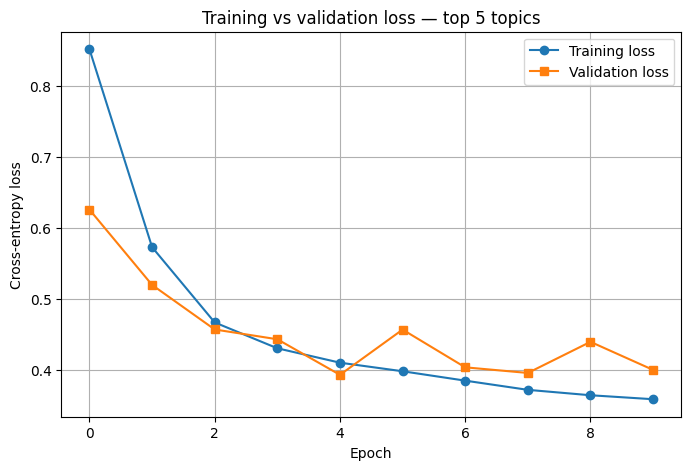

Saved: Multiclass_Pytorch_ArticleTopics_LossCurve_5.png


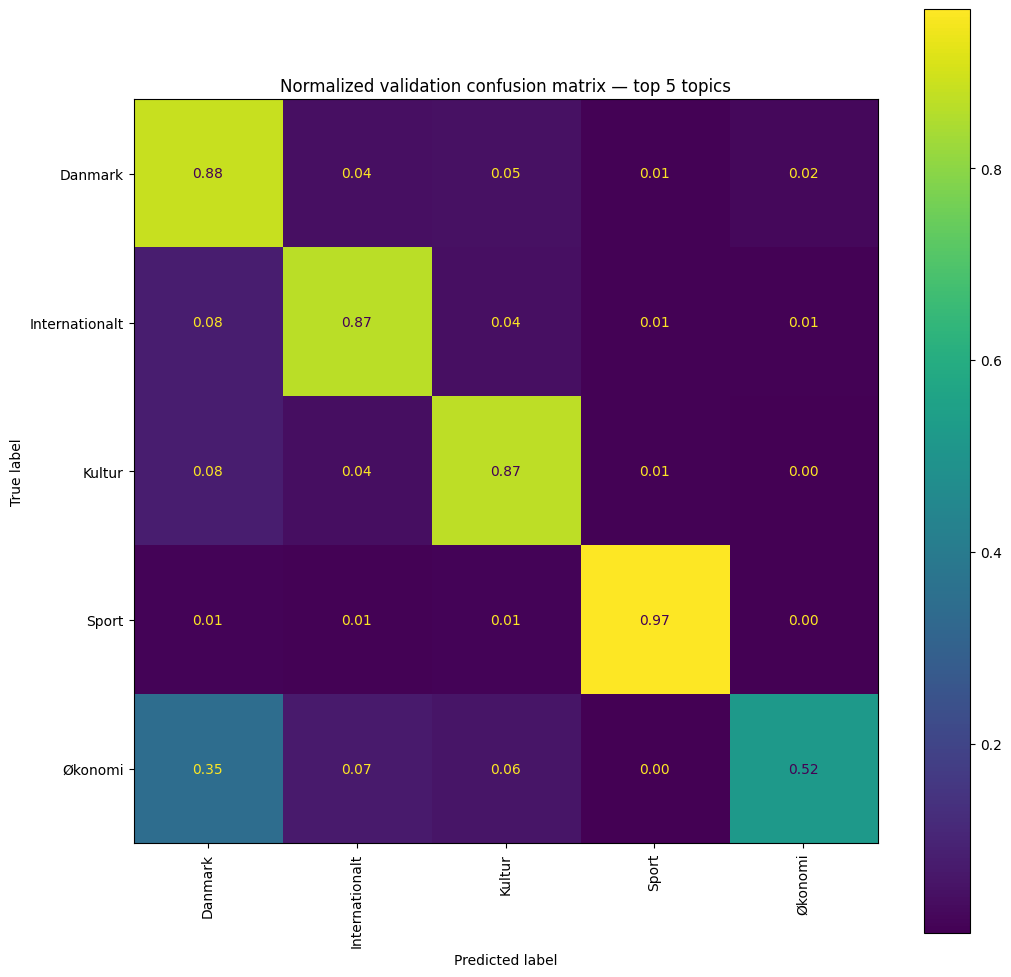

Saved: Multiclass_Pytorch_ArticleTopics_ConfusionMatrix_5.png


In [11]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn
import torch.optim as optim

import numpy as np
import matplotlib.pyplot as plt

# ========================================================
# SETTINGS
# ========================================================

TOP_X = 5
BATCH_SIZE = 32
EPOCHS = 10
LR = 1e-3
RANDOM_STATE = 42

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

PLOT_PREFIX = f"Multiclass_Pytorch_ArticleTopics"

# ========================================================
# PREPARE TOPIC LABELS
# ========================================================
# labels_articles_all columns:
# 0 = date
# 1 = sermon flag
# 2 = article title
# 3 = article topic
# 4 = lix score

topics_all = labels_articles_all[:, 3]

unique_topics, topic_counts = np.unique(topics_all, return_counts=True)
sorted_idx = np.argsort(topic_counts)[::-1]

top_topics = unique_topics[sorted_idx[:TOP_X]]
top_counts = topic_counts[sorted_idx[:TOP_X]]

print(f"\nTop {TOP_X} topics:")
for topic, count in zip(top_topics, top_counts):
    print(f"{topic}: {count}")

top_topic_mask = np.isin(topics_all, top_topics)

X = data_articles_all[top_topic_mask]
topics = topics_all[top_topic_mask]

print("\nFiltered data shape:", X.shape)
print("Filtered labels shape:", topics.shape)

# ========================================================
# ENCODE TEXT LABELS AS INTEGERS
# ========================================================

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(topics)

num_classes = len(label_encoder.classes_)
input_dim = X.shape[1]

print("\nClasses:", label_encoder.classes_)
print("Number of classes:", num_classes)
print("Input dimension:", input_dim)

# ========================================================
# TRAIN / VALIDATION / TEST SPLIT
# ========================================================

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=RANDOM_STATE,
    stratify=y_temp
)

# ========================================================
# PYTORCH DATASET
# ========================================================

class SparseDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        x = self.X[idx].toarray().ravel().astype(np.float32)
        y = self.y[idx]
        return torch.from_numpy(x), torch.tensor(y, dtype=torch.long)


train_loader = DataLoader(
    SparseDataset(X_train, y_train),
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    SparseDataset(X_val, y_val),
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    SparseDataset(X_test, y_test),
    batch_size=BATCH_SIZE,
    shuffle=False
)

# ========================================================
# MODEL
# ========================================================

class ArticleTopicClassifier(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, 192),
            nn.ReLU(),
            nn.Linear(192, 48),
            nn.ReLU(),
            nn.Linear(48, num_classes)
        )

    def forward(self, x):
        return self.net(x)


model = ArticleTopicClassifier(input_dim, num_classes).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

# ========================================================
# TRAINING FUNCTION
# ========================================================

def run_epoch(loader, training=True):
    if training:
        model.train()
    else:
        model.eval()

    total_loss = 0

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        if training:
            optimizer.zero_grad()

        logits = model(X_batch)
        loss = loss_fn(logits, y_batch)

        if training:
            loss.backward()
            optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

# ========================================================
# TRAIN MODEL
# ========================================================

train_losses = []
val_losses = []

for epoch in range(EPOCHS):
    train_loss = run_epoch(train_loader, training=True)

    with torch.no_grad():
        val_loss = run_epoch(val_loader, training=False)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(
        f"Epoch {epoch + 1:02d}/{EPOCHS} | "
        f"Train loss: {train_loss:.4f} | "
        f"Validation loss: {val_loss:.4f}"
    )

# ========================================================
# EVALUATION FUNCTION
# ========================================================

def get_predictions(loader):
    model.eval()

    all_preds = []
    all_true = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)

            logits = model(X_batch)
            preds = torch.argmax(logits, dim=1).cpu().numpy()

            all_preds.extend(preds)
            all_true.extend(y_batch.numpy())

    return np.array(all_true), np.array(all_preds)

# ========================================================
# VALIDATION RESULTS
# ========================================================

y_val_true, y_val_pred = get_predictions(val_loader)

print("\nValidation classification report:")
print(
    classification_report(
        y_val_true,
        y_val_pred,
        target_names=label_encoder.classes_
    )
)

# ========================================================
# TEST RESULTS
# ========================================================

y_test_true, y_test_pred = get_predictions(test_loader)

print("\nTest classification report:")
print(
    classification_report(
        y_test_true,
        y_test_pred,
        target_names=label_encoder.classes_
    )
)

# ========================================================
# PLOT AND SAVE TRAINING / VALIDATION LOSS
# ========================================================

plt.figure(figsize=(8, 5))
plt.plot(train_losses, marker="o", label="Training loss")
plt.plot(val_losses, marker="s", label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Cross-entropy loss")
plt.title(f"Training vs validation loss — top {TOP_X} topics")
plt.legend()
plt.grid(True)

loss_filename = f"{PLOT_PREFIX}_LossCurve_{TOP_X}.png"
plt.savefig(loss_filename, dpi=300, bbox_inches="tight")

plt.show()

print("Saved:", loss_filename)

# ========================================================
# NORMALIZED CONFUSION MATRIX
# ========================================================

cm = confusion_matrix(
    y_val_true,
    y_val_pred,
    normalize="true"   # normalize each row by the true class count
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

fig, ax = plt.subplots(figsize=(12, 12))

disp.plot(
    ax=ax,
    xticks_rotation=90,
    values_format=".2f"   # show normalized values with 2 decimals
)

plt.title(f"Normalized validation confusion matrix — top {TOP_X} topics")

cm_filename = f"{PLOT_PREFIX}_ConfusionMatrix_{TOP_X}.png"
plt.savefig(cm_filename, dpi=300, bbox_inches="tight")

plt.show()

print("Saved:", cm_filename)

Using device: cpu

Top 10 topics:
Internationalt: 76565
Danmark: 74975
Sport: 27420
Kultur: 20420
Økonomi: 16830
Politik: 14860
Fodbold: 9341
Forbrug: 7841
Film og tv: 7038
Sundhed: 6167

Filtered data shape: (261457, 27001)
Filtered labels shape: (261457,)

Classes: ['Danmark' 'Film og tv' 'Fodbold' 'Forbrug' 'Internationalt' 'Kultur'
 'Politik' 'Sport' 'Sundhed' 'Økonomi']
Number of classes: 10
Input dimension: 27001
Epoch 01/10 | Train loss: 1.2508 | Validation loss: 0.9241
Epoch 02/10 | Train loss: 0.8717 | Validation loss: 0.8317
Epoch 03/10 | Train loss: 0.7608 | Validation loss: 0.7745
Epoch 04/10 | Train loss: 0.7037 | Validation loss: 0.7044
Epoch 05/10 | Train loss: 0.6720 | Validation loss: 0.7016
Epoch 06/10 | Train loss: 0.6455 | Validation loss: 0.6549
Epoch 07/10 | Train loss: 0.6292 | Validation loss: 0.6619
Epoch 08/10 | Train loss: 0.6128 | Validation loss: 0.7294
Epoch 09/10 | Train loss: 0.5956 | Validation loss: 0.6189
Epoch 10/10 | Train loss: 0.5841 | Validation 

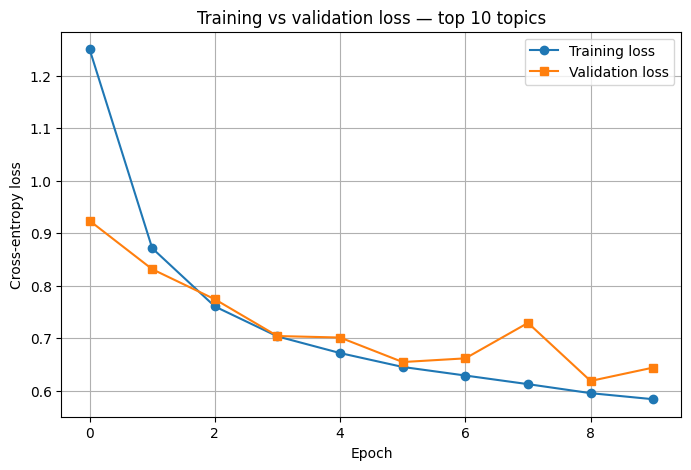

Saved: Multiclass_Pytorch_ArticleTopics_LossCurve_10.png


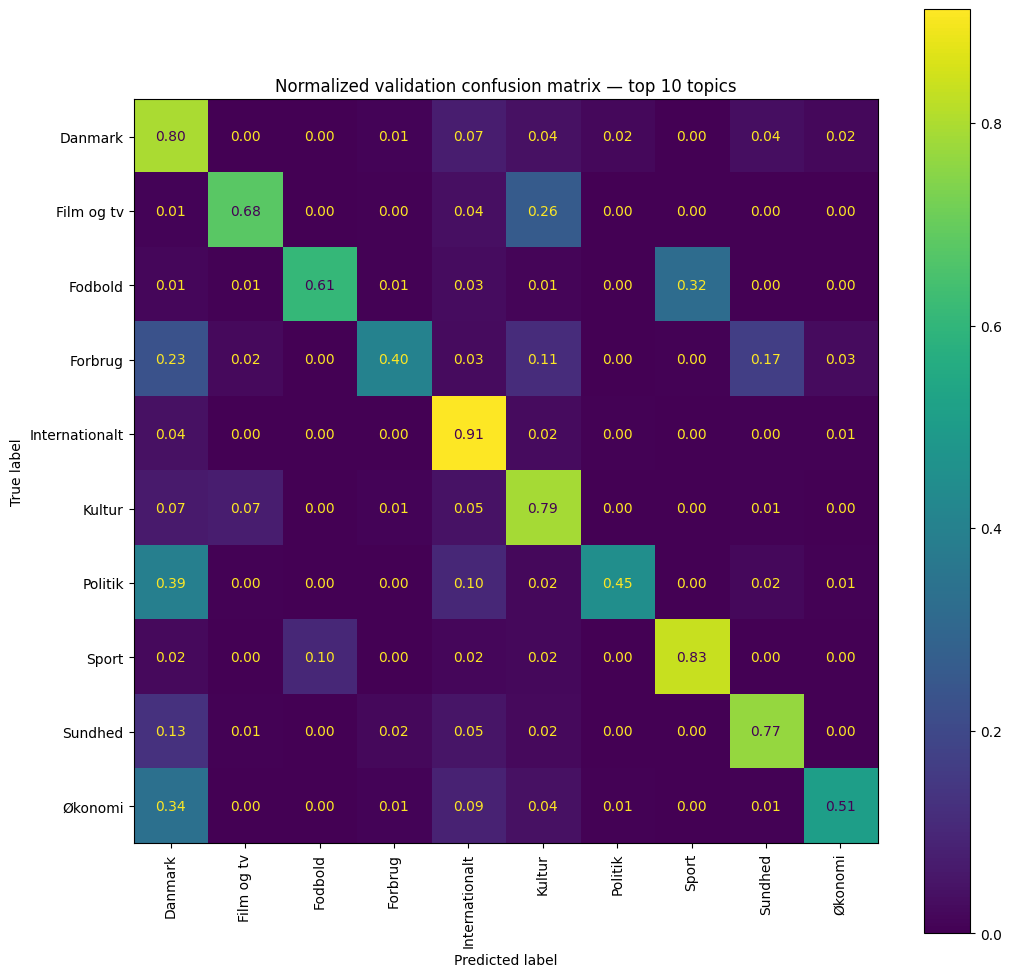

Saved: Multiclass_Pytorch_ArticleTopics_ConfusionMatrix_10.png


In [12]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn
import torch.optim as optim

import numpy as np
import matplotlib.pyplot as plt

# ========================================================
# SETTINGS
# ========================================================

TOP_X = 10
BATCH_SIZE = 32
EPOCHS = 10
LR = 1e-3
RANDOM_STATE = 42

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

PLOT_PREFIX = f"Multiclass_Pytorch_ArticleTopics"

# ========================================================
# PREPARE TOPIC LABELS
# ========================================================
# labels_articles_all columns:
# 0 = date
# 1 = sermon flag
# 2 = article title
# 3 = article topic
# 4 = lix score

topics_all = labels_articles_all[:, 3]

unique_topics, topic_counts = np.unique(topics_all, return_counts=True)
sorted_idx = np.argsort(topic_counts)[::-1]

top_topics = unique_topics[sorted_idx[:TOP_X]]
top_counts = topic_counts[sorted_idx[:TOP_X]]

print(f"\nTop {TOP_X} topics:")
for topic, count in zip(top_topics, top_counts):
    print(f"{topic}: {count}")

top_topic_mask = np.isin(topics_all, top_topics)

X = data_articles_all[top_topic_mask]
topics = topics_all[top_topic_mask]

print("\nFiltered data shape:", X.shape)
print("Filtered labels shape:", topics.shape)

# ========================================================
# ENCODE TEXT LABELS AS INTEGERS
# ========================================================

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(topics)

num_classes = len(label_encoder.classes_)
input_dim = X.shape[1]

print("\nClasses:", label_encoder.classes_)
print("Number of classes:", num_classes)
print("Input dimension:", input_dim)

# ========================================================
# TRAIN / VALIDATION / TEST SPLIT
# ========================================================

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=RANDOM_STATE,
    stratify=y_temp
)

# ========================================================
# PYTORCH DATASET
# ========================================================

class SparseDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        x = self.X[idx].toarray().ravel().astype(np.float32)
        y = self.y[idx]
        return torch.from_numpy(x), torch.tensor(y, dtype=torch.long)


train_loader = DataLoader(
    SparseDataset(X_train, y_train),
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    SparseDataset(X_val, y_val),
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    SparseDataset(X_test, y_test),
    batch_size=BATCH_SIZE,
    shuffle=False
)

# ========================================================
# MODEL
# ========================================================

class ArticleTopicClassifier(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, 192),
            nn.ReLU(),
            nn.Linear(192, 48),
            nn.ReLU(),
            nn.Linear(48, num_classes)
        )

    def forward(self, x):
        return self.net(x)


model = ArticleTopicClassifier(input_dim, num_classes).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

# ========================================================
# TRAINING FUNCTION
# ========================================================

def run_epoch(loader, training=True):
    if training:
        model.train()
    else:
        model.eval()

    total_loss = 0

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        if training:
            optimizer.zero_grad()

        logits = model(X_batch)
        loss = loss_fn(logits, y_batch)

        if training:
            loss.backward()
            optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

# ========================================================
# TRAIN MODEL
# ========================================================

train_losses = []
val_losses = []

for epoch in range(EPOCHS):
    train_loss = run_epoch(train_loader, training=True)

    with torch.no_grad():
        val_loss = run_epoch(val_loader, training=False)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(
        f"Epoch {epoch + 1:02d}/{EPOCHS} | "
        f"Train loss: {train_loss:.4f} | "
        f"Validation loss: {val_loss:.4f}"
    )

# ========================================================
# EVALUATION FUNCTION
# ========================================================

def get_predictions(loader):
    model.eval()

    all_preds = []
    all_true = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)

            logits = model(X_batch)
            preds = torch.argmax(logits, dim=1).cpu().numpy()

            all_preds.extend(preds)
            all_true.extend(y_batch.numpy())

    return np.array(all_true), np.array(all_preds)

# ========================================================
# VALIDATION RESULTS
# ========================================================

y_val_true, y_val_pred = get_predictions(val_loader)

print("\nValidation classification report:")
print(
    classification_report(
        y_val_true,
        y_val_pred,
        target_names=label_encoder.classes_
    )
)

# ========================================================
# TEST RESULTS
# ========================================================

y_test_true, y_test_pred = get_predictions(test_loader)

print("\nTest classification report:")
print(
    classification_report(
        y_test_true,
        y_test_pred,
        target_names=label_encoder.classes_
    )
)

# ========================================================
# PLOT AND SAVE TRAINING / VALIDATION LOSS
# ========================================================

plt.figure(figsize=(8, 5))
plt.plot(train_losses, marker="o", label="Training loss")
plt.plot(val_losses, marker="s", label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Cross-entropy loss")
plt.title(f"Training vs validation loss — top {TOP_X} topics")
plt.legend()
plt.grid(True)

loss_filename = f"{PLOT_PREFIX}_LossCurve_{TOP_X}.png"
plt.savefig(loss_filename, dpi=300, bbox_inches="tight")

plt.show()

print("Saved:", loss_filename)

# ========================================================
# NORMALIZED CONFUSION MATRIX
# ========================================================

cm = confusion_matrix(
    y_val_true,
    y_val_pred,
    normalize="true"   # normalize each row by the true class count
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

fig, ax = plt.subplots(figsize=(12, 12))

disp.plot(
    ax=ax,
    xticks_rotation=90,
    values_format=".2f"   # show normalized values with 2 decimals
)

plt.title(f"Normalized validation confusion matrix — top {TOP_X} topics")

cm_filename = f"{PLOT_PREFIX}_ConfusionMatrix_{TOP_X}.png"
plt.savefig(cm_filename, dpi=300, bbox_inches="tight")

plt.show()

print("Saved:", cm_filename)

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn
import torch.optim as optim

import numpy as np
import matplotlib.pyplot as plt

# ========================================================
# SETTINGS
# ========================================================

TOP_X = 20
BATCH_SIZE = 32
EPOCHS = 10
LR = 1e-3
RANDOM_STATE = 42

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

PLOT_PREFIX = f"Multiclass_Pytorch_ArticleTopics"

# ========================================================
# PREPARE TOPIC LABELS
# ========================================================
# labels_articles_all columns:
# 0 = date
# 1 = sermon flag
# 2 = article title
# 3 = article topic
# 4 = lix score

topics_all = labels_articles_all[:, 3]

unique_topics, topic_counts = np.unique(topics_all, return_counts=True)
sorted_idx = np.argsort(topic_counts)[::-1]

top_topics = unique_topics[sorted_idx[:TOP_X]]
top_counts = topic_counts[sorted_idx[:TOP_X]]

print(f"\nTop {TOP_X} topics:")
for topic, count in zip(top_topics, top_counts):
    print(f"{topic}: {count}")

top_topic_mask = np.isin(topics_all, top_topics)

X = data_articles_all[top_topic_mask]
topics = topics_all[top_topic_mask]

print("\nFiltered data shape:", X.shape)
print("Filtered labels shape:", topics.shape)

# ========================================================
# ENCODE TEXT LABELS AS INTEGERS
# ========================================================

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(topics)

num_classes = len(label_encoder.classes_)
input_dim = X.shape[1]

print("\nClasses:", label_encoder.classes_)
print("Number of classes:", num_classes)
print("Input dimension:", input_dim)

# ========================================================
# TRAIN / VALIDATION / TEST SPLIT
# ========================================================

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=RANDOM_STATE,
    stratify=y_temp
)

# ========================================================
# PYTORCH DATASET
# ========================================================

class SparseDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        x = self.X[idx].toarray().ravel().astype(np.float32)
        y = self.y[idx]
        return torch.from_numpy(x), torch.tensor(y, dtype=torch.long)


train_loader = DataLoader(
    SparseDataset(X_train, y_train),
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    SparseDataset(X_val, y_val),
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    SparseDataset(X_test, y_test),
    batch_size=BATCH_SIZE,
    shuffle=False
)

# ========================================================
# MODEL
# ========================================================

class ArticleTopicClassifier(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, 192),
            nn.ReLU(),
            nn.Linear(192, 48),
            nn.ReLU(),
            nn.Linear(48, num_classes)
        )

    def forward(self, x):
        return self.net(x)


model = ArticleTopicClassifier(input_dim, num_classes).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

# ========================================================
# TRAINING FUNCTION
# ========================================================

def run_epoch(loader, training=True):
    if training:
        model.train()
    else:
        model.eval()

    total_loss = 0

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        if training:
            optimizer.zero_grad()

        logits = model(X_batch)
        loss = loss_fn(logits, y_batch)

        if training:
            loss.backward()
            optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

# ========================================================
# TRAIN MODEL
# ========================================================

train_losses = []
val_losses = []

for epoch in range(EPOCHS):
    train_loss = run_epoch(train_loader, training=True)

    with torch.no_grad():
        val_loss = run_epoch(val_loader, training=False)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(
        f"Epoch {epoch + 1:02d}/{EPOCHS} | "
        f"Train loss: {train_loss:.4f} | "
        f"Validation loss: {val_loss:.4f}"
    )

# ========================================================
# EVALUATION FUNCTION
# ========================================================

def get_predictions(loader):
    model.eval()

    all_preds = []
    all_true = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)

            logits = model(X_batch)
            preds = torch.argmax(logits, dim=1).cpu().numpy()

            all_preds.extend(preds)
            all_true.extend(y_batch.numpy())

    return np.array(all_true), np.array(all_preds)

# ========================================================
# VALIDATION RESULTS
# ========================================================

y_val_true, y_val_pred = get_predictions(val_loader)

print("\nValidation classification report:")
print(
    classification_report(
        y_val_true,
        y_val_pred,
        target_names=label_encoder.classes_
    )
)

# ========================================================
# TEST RESULTS
# ========================================================

y_test_true, y_test_pred = get_predictions(test_loader)

print("\nTest classification report:")
print(
    classification_report(
        y_test_true,
        y_test_pred,
        target_names=label_encoder.classes_
    )
)

# ========================================================
# PLOT AND SAVE TRAINING / VALIDATION LOSS
# ========================================================

plt.figure(figsize=(8, 5))
plt.plot(train_losses, marker="o", label="Training loss")
plt.plot(val_losses, marker="s", label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Cross-entropy loss")
plt.title(f"Training vs validation loss — top {TOP_X} topics")
plt.legend()
plt.grid(True)

loss_filename = f"{PLOT_PREFIX}_LossCurve_{TOP_X}.png"
plt.savefig(loss_filename, dpi=300, bbox_inches="tight")

plt.show()

print("Saved:", loss_filename)

# ========================================================
# NORMALIZED CONFUSION MATRIX
# ========================================================

cm = confusion_matrix(
    y_val_true,
    y_val_pred,
    normalize="true"   # normalize each row by the true class count
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

fig, ax = plt.subplots(figsize=(12, 12))

disp.plot(
    ax=ax,
    xticks_rotation=90,
    values_format=".2f"   # show normalized values with 2 decimals
)

plt.title(f"Normalized validation confusion matrix — top {TOP_X} topics")

cm_filename = f"{PLOT_PREFIX}_ConfusionMatrix_{TOP_X}.png"
plt.savefig(cm_filename, dpi=300, bbox_inches="tight")

plt.show()

print("Saved:", cm_filename)

Using device: cpu

Top 20 topics:
Internationalt: 76565
Danmark: 74975
Sport: 27420
Kultur: 20420
Økonomi: 16830
Politik: 14860
Fodbold: 9341
Forbrug: 7841
Film og tv: 7038
Sundhed: 6167
Leder: 5835
Debatindlæg: 5784
Debat: 5383
Bøger: 5107
Cykling: 4761
Kroniken: 4457
Musik: 4369
Virksomheder: 4336
Rejser: 3989
Superligaen: 3971

Filtered data shape: (309449, 27001)
Filtered labels shape: (309449,)

Classes: ['Bøger' 'Cykling' 'Danmark' 'Debat' 'Debatindlæg' 'Film og tv' 'Fodbold'
 'Forbrug' 'Internationalt' 'Kroniken' 'Kultur' 'Leder' 'Musik' 'Politik'
 'Rejser' 'Sport' 'Sundhed' 'Superligaen' 'Virksomheder' 'Økonomi']
Number of classes: 20
Input dimension: 27001
Epoch 01/10 | Train loss: 1.6550 | Validation loss: 1.2825
Epoch 02/10 | Train loss: 1.1918 | Validation loss: 1.0891
Epoch 03/10 | Train loss: 1.0265 | Validation loss: 1.0230
Epoch 04/10 | Train loss: 0.9222 | Validation loss: 0.9751
Epoch 05/10 | Train loss: 0.8577 | Validation loss: 0.8378
Epoch 06/10 | Train loss: 0.814